#  1. Data Review

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

pio.templates.default = "plotly_white"

## 1.1 Data Loading

| Column | Description |
| :--- | :--- |
| **customerID** | Unique ID identifying each customer |
| **gender** | Customer gender (Male, Female) |
| **SeniorCitizen** | Indicates if the customer is 65 or older (1, 0) |
| **Partner** | Indicates if the customer has a partner (Yes, No) |
| **Dependents** | Indicates if the customer lives with any dependents (Yes, No) |
| **tenure** | Number of months the customer has been with the company |
| **PhoneService** | Subscribes to home phone service (Yes, No) |
| **MultipleLines** | Subscribes to multiple telephone lines (Yes, No, No phone service) |
| **InternetService** | Internet service provider (DSL, Fiber optic, No) |
| **OnlineSecurity** | Additional online security service (Yes, No, No internet service) |
| **OnlineBackup** | Additional online backup service (Yes, No, No internet service) |
| **DeviceProtection** | Device protection plan for equipment (Yes, No, No internet service) |
| **TechSupport** | Technical support plan with reduced wait times (Yes, No, No internet service) |
| **StreamingTV** | Uses Internet service to stream TV (Yes, No, No internet service) |
| **StreamingMovies** | Uses Internet service to stream movies (Yes, No, No internet service) |
| **Contract** | Current contract type (Month-to-month, One year, Two year) |
| **PaperlessBilling** | Chosen paperless billing (Yes, No) |
| **PaymentMethod** | Customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card) |
| **MonthlyCharges** | Total monthly charge for all services |
| **TotalCharges** | Overall total charges to date |
| **CustomerSatisfactionScore** | Satisfaction survey score (1-10) |
| **Churn** | Target: Whether the customer left this quarter (Yes, No) |

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head(20)
# df[df['tenure'] == 0].head(20)

Dataset loaded with 7043 rows and 22 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CustomerSatisfactionScore,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,NaN,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,NaN,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,6.0,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),NaN,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,1.0,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,5.0,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),NaN,89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,No,Mailed check,NaN,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,4.0,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),NaN,56.15,3487.95,No


## 1.2 Basic Data Overview

In [3]:
summary = df.describe(include=['object', 'string']).T
summary['dtype'] = df.dtypes
display(summary)

,count,unique,top,freq,dtype
customerID,7043,7043,7590-VHVEG,1,str
gender,7043,2,Male,3555,str
Partner,7043,2,No,3641,str
Dependents,7043,2,No,4933,str
PhoneService,7043,2,Yes,6361,str
MultipleLines,7043,3,No,3390,str
InternetService,7043,3,Fiber optic,3096,str
OnlineSecurity,7043,3,No,3498,str
OnlineBackup,7043,3,No,3088,str
DeviceProtection,7043,3,No,3095,str


## 1.3 Data Quality & Cleaning

In [4]:
# TotalCharges: str -> numeric + nulls as 0 because all those having tenure=0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Convert boolean columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: True, 0: False}).astype(bool)
df['Partner'] = df['Partner'].map({'Yes': True, 'No': False}).astype(bool)
df['Dependents'] = df['Dependents'].map({'Yes': True, 'No': False}).astype(bool)
df['PhoneService'] = df['PhoneService'].map({'Yes': True, 'No': False}).astype(bool)
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': True, 'No': False}).astype(bool)
df['Churn'] = df['Churn'].map({'Yes': True, 'No': False}).astype(bool)


### Missing values and duplicates

In [5]:
# nulls
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# empty strings
object_cols = df.select_dtypes(include=['object', 'string']).columns
empty_strings = {col: (df[col] == '').sum() for col in object_cols}
print("\nEmpty strings ('') per object column:")
for col, count in empty_strings.items():
    if count > 0:
        print(f"{col}: {count}")

# duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Missing values per column:
CustomerSatisfactionScore    5174
dtype: int64

Empty strings ('') per object column:
Number of duplicate rows: 0


## 1.4 Visual analysis

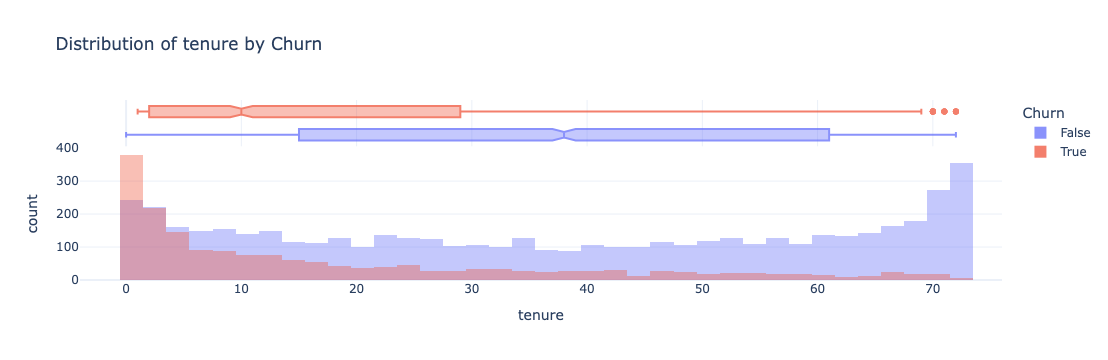

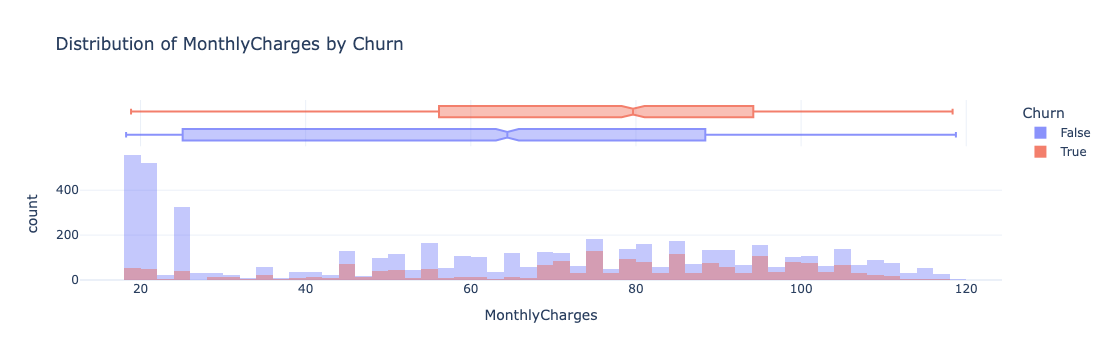

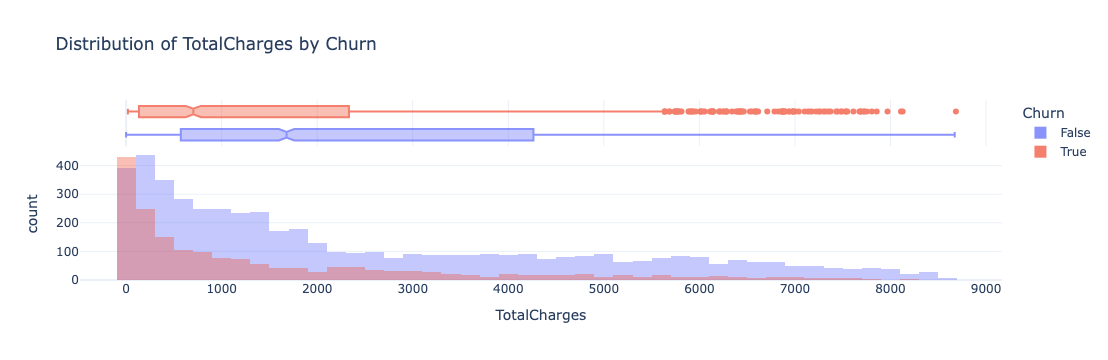

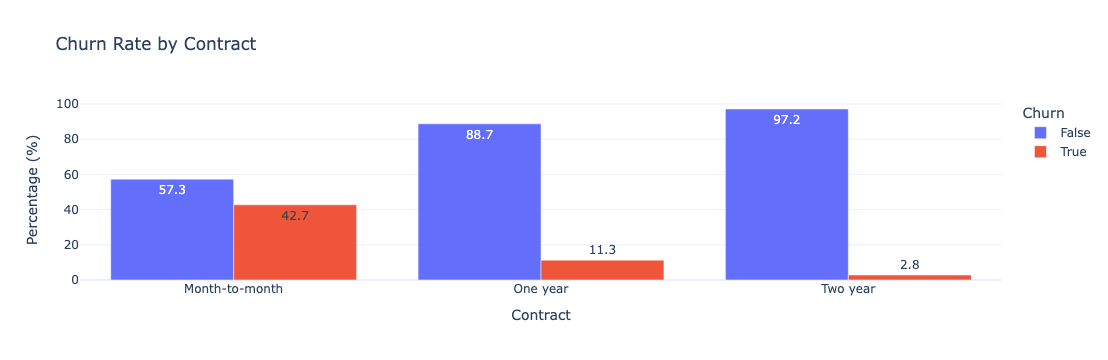

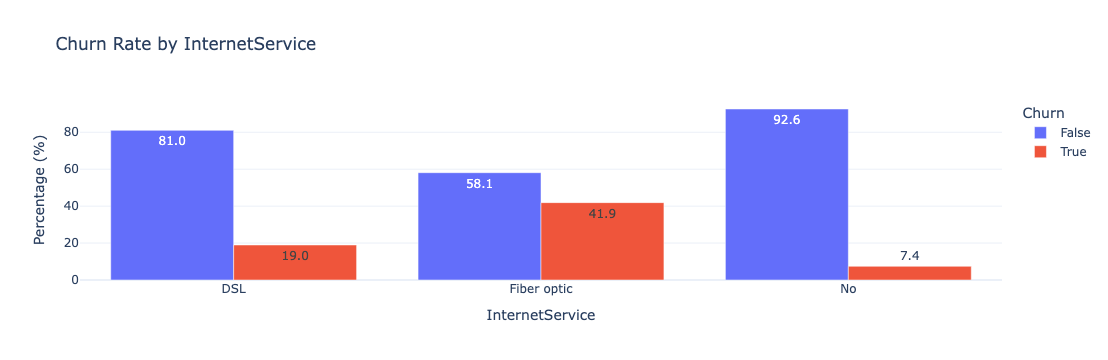

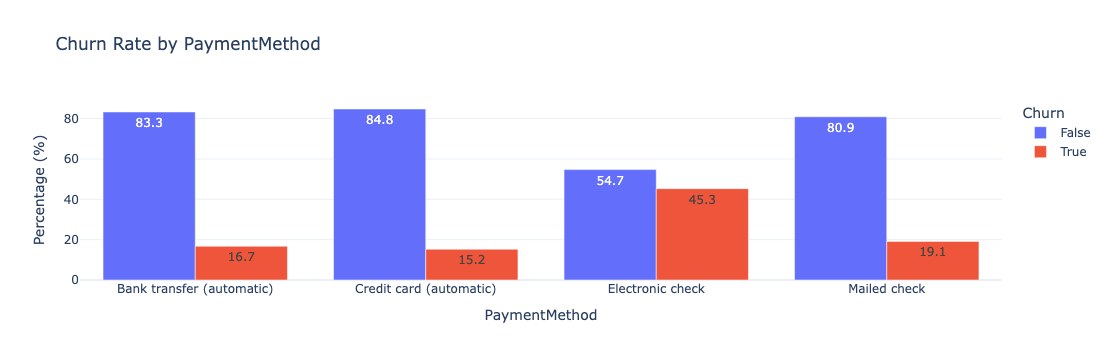

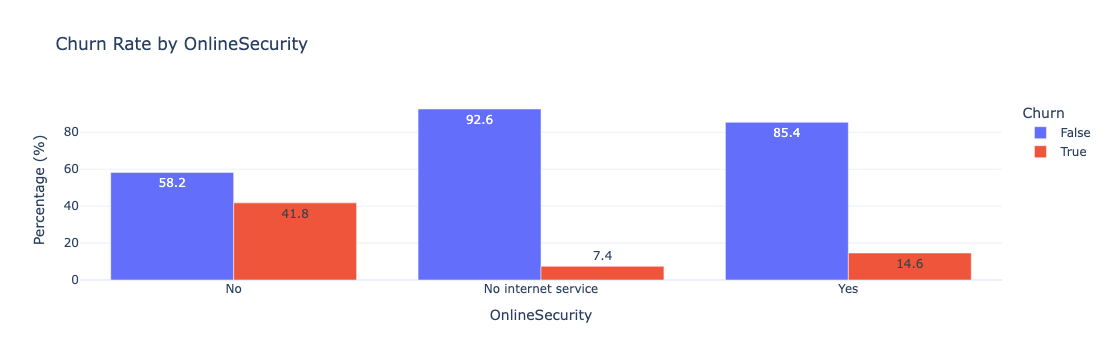

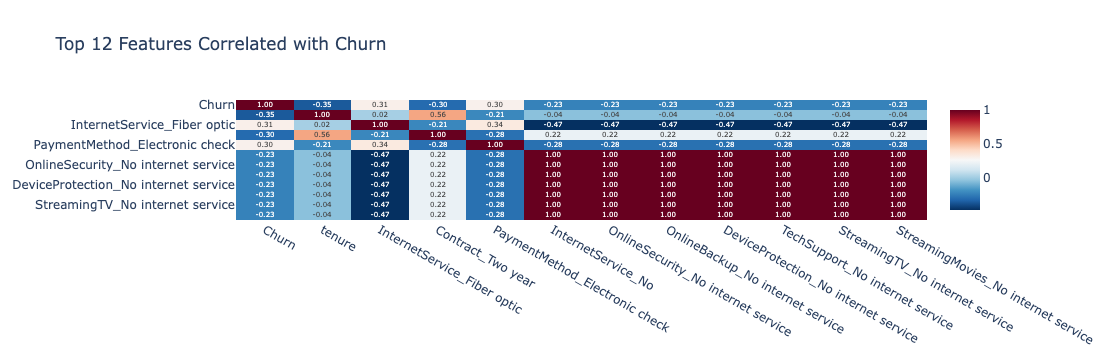

In [6]:
# ---------------------------------------------------------
# 1. NUMERICAL FEATURES vs CHURN
# ---------------------------------------------------------
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    fig_num = px.histogram(
        df, x=col, color='Churn', 
        barmode='overlay',
        marginal='box', # Adds a boxplot above the histogram
        title=f'Distribution of {col} by Churn',
        color_discrete_sequence=['#636EFA', '#EF553B']
    )
    fig_num.update_traces(opacity=0.75)
    fig_num.show()

# ---------------------------------------------------------
# 2. CATEGORICAL FEATURES vs CHURN
# ---------------------------------------------------------
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']

for col in cat_cols:
    # Calculate churn rate percentage
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).rename('Percentage').mul(100).reset_index()
    
    fig_cat = px.bar(
        churn_rate, x=col, y='Percentage', color='Churn', barmode='group',
        title=f'Churn Rate by {col}',
        labels={'Percentage': 'Percentage (%)'},
        text_auto='.1f', # Shows exact percentage on bars
        color_discrete_sequence=['#636EFA', '#EF553B']
    )
    fig_cat.show()

# ---------------------------------------------------------
# 3. CORRELATION HEATMAP (Feature Importance)
# ---------------------------------------------------------
df_corr = df.drop(columns=['customerID', 'CustomerSatisfactionScore'], errors='ignore').copy()

df_corr = pd.get_dummies(df_corr, drop_first=True)

# Get top 12 features most correlated with Churn
top_features = df_corr.corr()['Churn'].abs().nlargest(12).index
corr_matrix = df_corr[top_features].corr()

fig_corr = px.imshow(
    corr_matrix, 
    text_auto='.2f', 
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title='Top 12 Features Correlated with Churn'
)
fig_corr.show()

# 2. Train the model and predict

In [9]:
# 1. Define Features (X) and Target (y)
X = df_corr.drop(columns=['Churn'])
y = df_corr['Churn']

# 2. Split the Data (80% Train, 20% Test)
# stratify=y ensures the 73/27 churn ratio is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize the Model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 4. Train the Model
model.fit(X_train, y_train)

# 5. Make Predictions on unseen test data
y_pred = model.predict(X_test)

#adjust threshold!
y_pred_probs = model.predict_proba(X_test)[:, 1] 
custom_threshold = 0.30
y_pred_custom = (y_pred_probs >= custom_threshold).astype(int)

# 6. Evaluate the Performance
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

# Optional: View feature importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Most Important Features:")
print(importance.head(5))




y_pred_custom = (y_pred_probs >= custom_threshold).astype(int)

Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.76      0.82      1035
        True       0.52      0.72      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409


Top 5 Most Important Features:
TotalCharges                      0.179221
tenure                            0.163997
MonthlyCharges                    0.152836
Contract_Two year                 0.053742
PaymentMethod_Electronic check    0.040967
dtype: float64


# 3. How to improve?

### Add more features:
 - Compatitors offerings
 - Usage stats
 - Support issues / requests

### Tweaking:
 - Feature Engineering (combine, bins)
 - Hyperparameter Tuning (number of trees, depth)
 - Try other algorithms (boosting)